In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


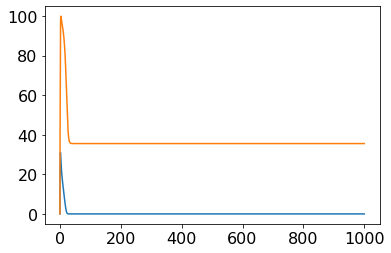

In [27]:
aln = ALNModel()

aln.params['duration'] = 1000.

control0 = aln.getZeroControl()

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# no noise
aln.params.sigma_ou = 0.

# NO DELAY
aln.params.de = 0.
aln.params.di = 0.
aln.params.signalV = 0.

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2))
steady_rates[0] = np.mean(state[0,0,-1]) #  state exc
steady_rates[1] = np.mean(state[0,1,-1]) #  state inh

state_vars = aln.state_vars
init_vars = aln.init_vars

steady_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        steady_vars[i] = aln.state[state_vars[i]][0] * 1.01
    else:
        steady_vars[i] = aln.state[state_vars[i]][0,-1] * 1.01

In [28]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

In [29]:
dur = 15.
dur_pre = 0.5
dur_post = 0.5
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = steady_rates[0]*1.5
target[:,1,:] = steady_rates[1]+15.

tol = 1e-22
incl_step = int(1. + aln.params.duration/aln.params.dt)
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

alg = "A1"
#alg = "A2"

In [39]:
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.

setinitvars(steady_vars)
max_it = 1
start_step = 10.
alg = "A1"
case = "A"

t_range = np.arange(10., 11., 10.)
runtimeA1 = np.zeros(( len(t_range)+1, max_it + 1 ))

for d in range(len(t_range)):
    print("--------------------------------")
    print("duration = ", t_range[d])
    aln.params.duration = t_range[d]

    control0 = aln.getZeroControl()
    target = aln.getZeroTarget()
    target[:,0,:] = steady_rates[0]*1.5
    target[:,1,:] = steady_rates[1]+15.

    control0 = aln.getZeroControl()

    if alg == "A1":
        %prun bestControlA, bestStateA, costA, runtime_ = aln.A1(control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = t_range[d], t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlA, bestStateA, costA, runtime_ = aln.A2(control0, target, max_iteration_ = max_it,
            tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
            max_control_ = max_cntrl, t_sim_ = t_range[d], t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
        
    runtimeA1[d,:] = runtime_

set cost params
--------------------------------
duration =  10.0
RUN  0 , total integrated cost =  1114.611945659453


D:\Promotion\neurolib\neurolib\utils\A1_aln_control.py:522: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (array(float64, 1d, A), array(float64, 2d, C))
  res = np.dot(phi_[0,:,t-1], jac_u_) # shift if control is applied shifted wrt mu


TypeError: f_int() missing 2 required positional arguments: 'target_' and 'control_'

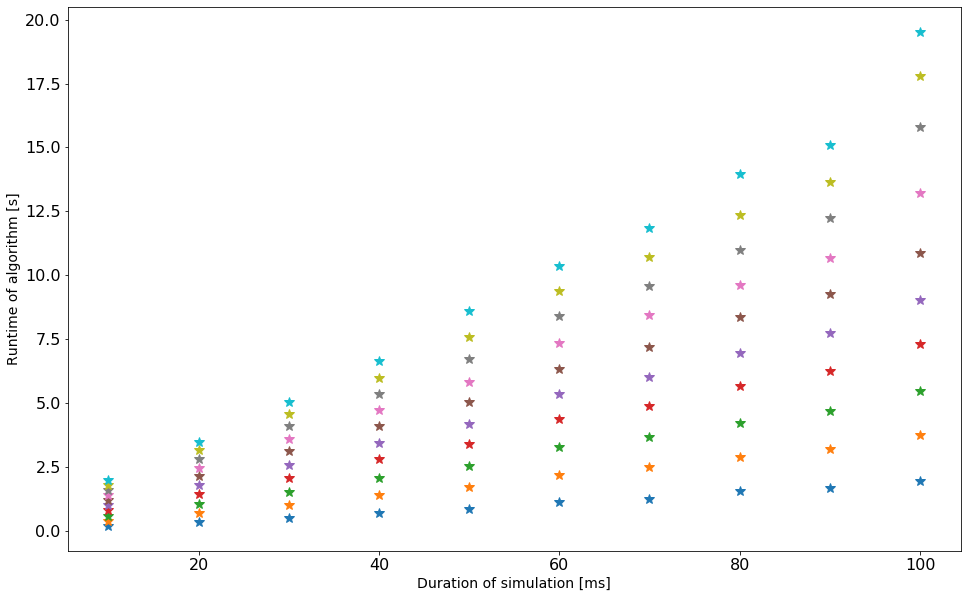

In [62]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
          "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

fig, ax = plt.subplots(figsize=(16,10))
for i in range(len(t_range)):
    for j in range(1, runtimeA1.shape[1]):
        ax.plot(t_range[i], runtimeA1[i,j], "*", markersize = 10, c=colors[j-1])

ax.set_xlabel("Duration of simulation [ms]")
ax.set_ylabel("Runtime of algorithm [s]")
        
plt.savefig(os.path.join(path, "runtime_A1.png"))
plt.show()

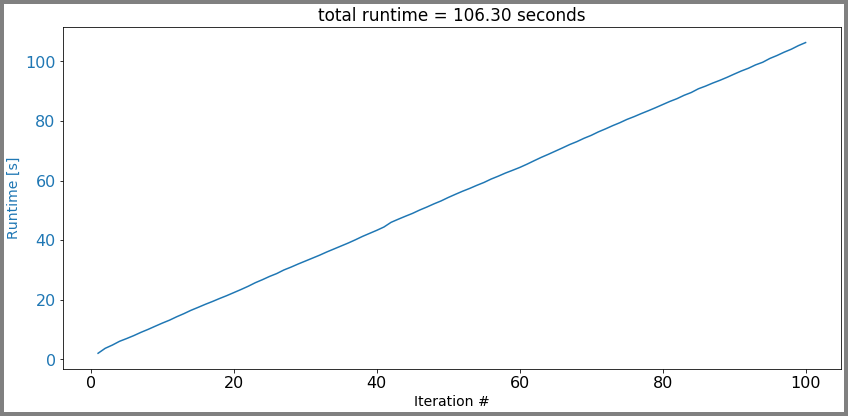

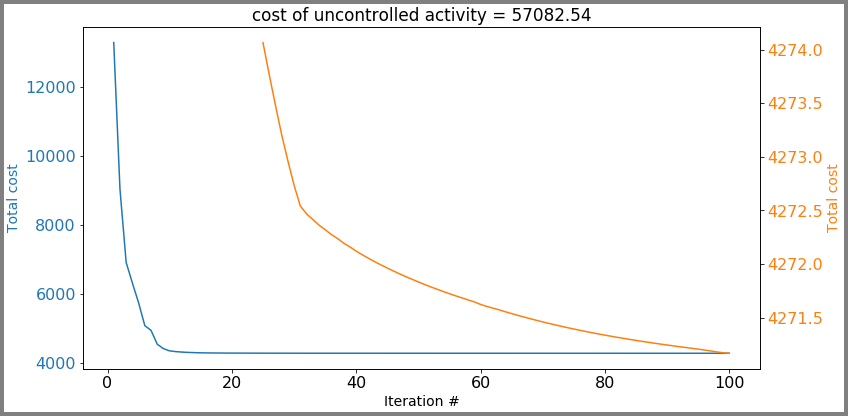

In [8]:
plotFunc.plot_runtime(runtimeA, path, str("p1_e1_s1_u1nA_LowHigh_runtime_" + case + "_" + alg) )
plotFunc.plot_convergence(costA, path, str("p1_e1_s1_u1nA_LowHigh_cost_" + case + "_" + alg) )

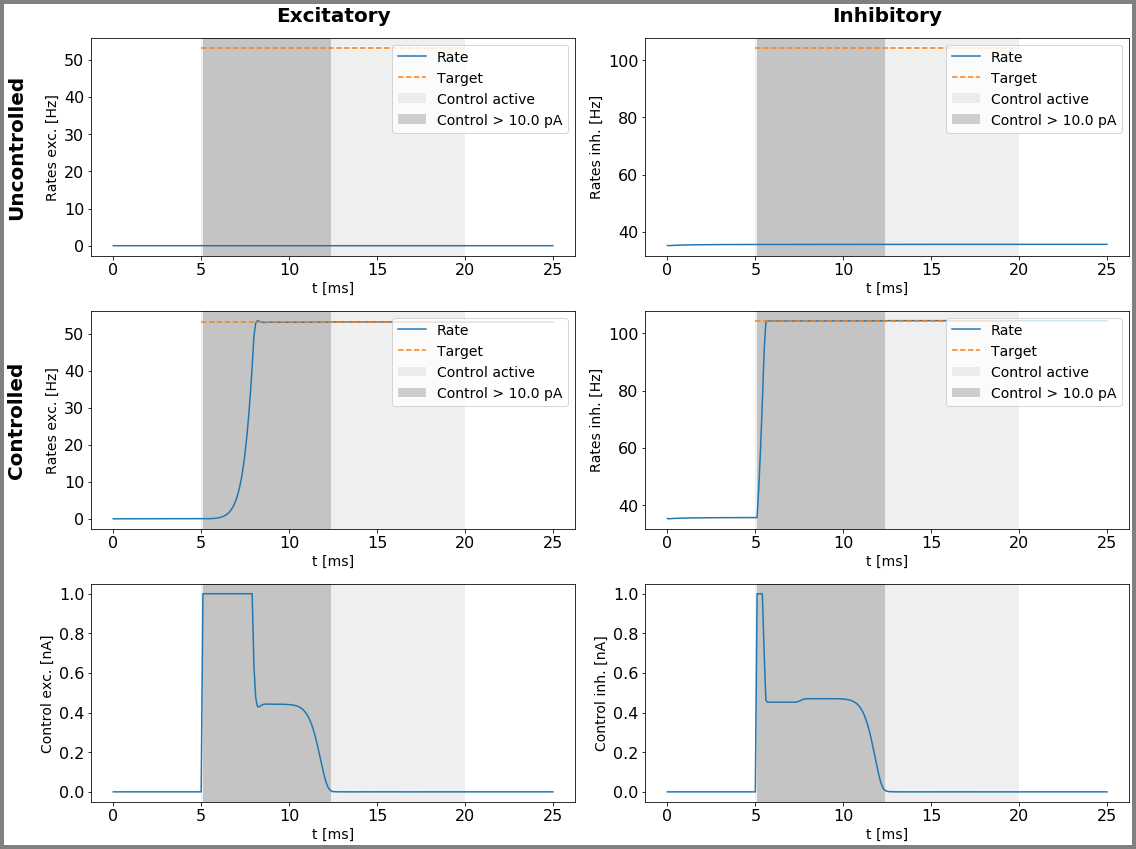

In [9]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, low_state_vars, target,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))